# CSC 1105 Mathematics for Computer Science  
## Lab: Limits and Continuity with Python

**Course topic:** Limits and Continuity  
**Tools:** NumPy, Pandas, Matplotlib, SymPy, and SciPy

### Purpose of this lab
This notebook turns the lecture material on limits and continuity into a computational laboratory. We will use Python to explore limits from the **numerical, graphical, and algebraic** viewpoints, and then connect continuity to the Intermediate Value Theorem, differentiability, rates of change, and optimization.

### Learning outcomes
By the end of the lab, you should be able to:

1. Estimate a limit numerically by approaching a point from both sides.
2. Visualize removable, jump, and infinite discontinuities.
3. Compute exact limits symbolically with SymPy.
4. Verify one-sided limits and test continuity at a point.
5. Investigate indeterminate forms such as \(0/0\).
6. Explore limits at infinity and horizontal asymptotes.
7. Use the Intermediate Value Theorem together with SciPy root-finding.
8. Relate continuity to differentiability.
9. Use derivatives for rates of change and numerical optimization.

> **Important:** SciPy does not provide a general symbolic `limit()` function.  
> In this lab:
> - **NumPy/Pandas** are used for numerical experiments and tables.
> - **Matplotlib** is used for graphs.
> - **SymPy** is used for exact symbolic limits and derivatives.
> - **SciPy** is used for numerical root-finding and optimization.

## 0. Setup

Run the next cell first. It imports all packages used in the lab and prints their versions.

If you are working in Google Colab, the required packages are normally already installed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import scipy
from scipy import optimize
from IPython.display import display

# Make numerical output easier to read.
np.set_printoptions(precision=8, suppress=True)

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("SymPy :", sp.__version__)
print("SciPy :", scipy.__version__)

NumPy : 1.24.3
Pandas: 2.0.3
SymPy : 1.14.0
SciPy : 1.11.1


## 1. The numerical meaning of a limit

The lecture notes use


$f(x)=\frac{x^2-1}{x-1}, \qquad x\ne 1,$

to illustrate an important idea:


$\lim_{x\to 1} f(x)=2$


even though $f(1)$ is not defined.

A limit is about what happens **near** the point, not necessarily at the point itself.

We first approach $x=1$ from both sides.

In [2]:
def f_removable(x):
    # The formula is undefined at x = 1.
    return (x**2 - 1) / (x - 1)

x_values = np.array([
    0.9, 0.99, 0.999, 0.9999,
    1.0001, 1.001, 1.01, 1.1
])

table = pd.DataFrame({
    "x": x_values,
    "f(x)": f_removable(x_values),
    "|x - 1|": np.abs(x_values - 1)
})

display(table)

,x,f(x),|x - 1|
0,0.9000,1.9000,0.1000
1,0.9900,1.9900,0.0100
2,0.9990,1.9990,0.0010
3,0.9999,1.9999,0.0001
4,1.0001,2.0001,0.0001
5,1.0010,2.0010,0.0010
6,1.0100,2.0100,0.0100
7,1.1000,2.1000,0.1000


### Observation

As \(x\) moves closer to \(1\), the values of \(f(x)\) move closer to \(2\).

The next helper function will be useful throughout the notebook. It samples points close to \(a\) from the left and the right.

In [3]:
def numerical_limit_table(func, a, powers=range(1, 7)):
    """Create a table of values approaching a from the left and right.

    Parameters
    ----------
    func : callable
        A Python function f(x).
    a : float
        Point being approached.
    powers : iterable
        Uses distances 10^(-p).

    Returns
    -------
    pandas.DataFrame
        x-values and function values from both sides.
    """
    rows = []

    for p in powers:
        h = 10.0**(-p)

        x_left = a - h
        x_right = a + h

        rows.append({
            "h": h,
            "x_left": x_left,
            "f(x_left)": func(x_left),
            "x_right": x_right,
            "f(x_right)": func(x_right)
        })

    return pd.DataFrame(rows)

display(numerical_limit_table(f_removable, 1))

,h,x_left,f(x_left),x_right,f(x_right)
0,0.100000,0.900000,1.900000,1.100000,2.100000
1,0.010000,0.990000,1.990000,1.010000,2.010000
2,0.001000,0.999000,1.999000,1.001000,2.001000
3,0.000100,0.999900,1.999900,1.000100,2.000100
4,0.000010,0.999990,1.999990,1.000010,2.000010
5,0.000001,0.999999,1.999999,1.000001,2.000001


## 2. Graphical view: a hole can exist while the limit exists

Algebraically,


$\frac{x^2-1}{x-1}
= \frac{(x-1)(x+1)}{x-1}
= x+1.$

So the graph follows the straight line $y=x+1$, except that the original expression has a hole at $(1,2)$.

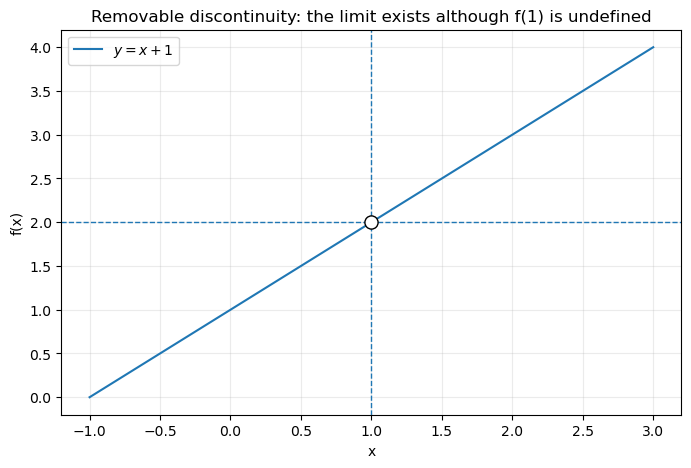

In [4]:
x_plot = np.linspace(-1, 3, 500)

# We plot the simplified expression y = x + 1.
y_plot = x_plot + 1

plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, label=r"$y=x+1$")

# Draw an open circle to represent the missing value at x=1.
plt.scatter([1], [2], facecolors="white", edgecolors="black", s=90, zorder=5)

plt.axvline(1, linestyle="--", linewidth=1)
plt.axhline(2, linestyle="--", linewidth=1)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Removable discontinuity: the limit exists although f(1) is undefined")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 3. Symbolic limits with SymPy

For exact algebraic work, define a symbolic variable and use `sp.limit(expression, variable, point)`.

SymPy can often simplify the expression automatically.

In [5]:
x = sp.symbols("x", real=True)

expr = (x**2 - 1) / (x - 1)

exact_limit = sp.limit(expr, x, 1)
simplified_expr = sp.simplify(expr)

print("Original expression:", expr)
print("Simplified expression:", simplified_expr)
print("Exact limit as x -> 1:", exact_limit)

Original expression: (x**2 - 1)/(x - 1)
Simplified expression: x + 1
Exact limit as x -> 1: 2


### Compare the three viewpoints

For the same example:

- **Numerical:** values close to \(x=1\) are close to \(2\).
- **Graphical:** the curve approaches the point \((1,2)\) from both sides.
- **Algebraic:** factoring and cancellation give \(x+1\), whose value approaches \(2\).

A strong understanding of limits uses all three viewpoints.

## 4. One-sided limits

For a two-sided limit to exist,


$\lim_{x\to a^-}f(x)=\lim_{x\to a^+}f(x).$

Consider the lecture example


$f(x)=
\begin{cases}
x+2, & x<1,\\
4, & x=1,\\
3x, & x>1.
\end{cases}$

The left-hand and right-hand limits are both $3$, even though $f(1)=4$.

In [6]:
# Define the branches
left_branch = x + 2
right_branch = 3*x

# Compute one-sided limits from the appropriate branch
left_limit = sp.limit(left_branch, x, 1, dir="-")
right_limit = sp.limit(right_branch, x, 1, dir="+")

# Function value at x = 1
f_at_1 = 4

print("Left-hand limit :", left_limit)
print("Right-hand limit:", right_limit)
print("Function value f(1):", f_at_1)

Left-hand limit : 3
Right-hand limit: 3
Function value f(1): 4


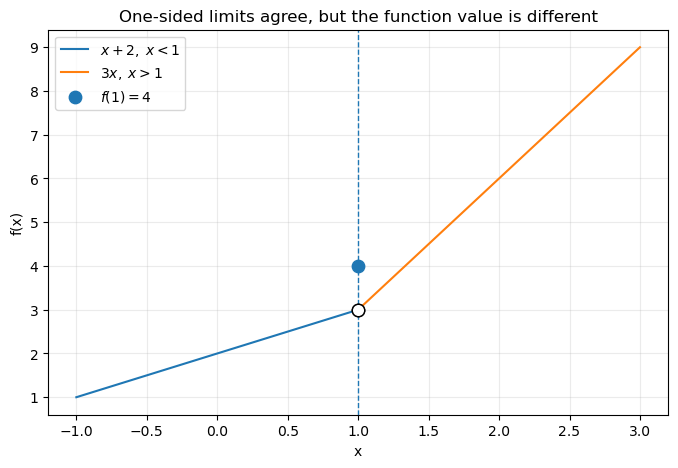

In [7]:
def f_piecewise(values):
    values = np.asarray(values)
    return np.where(values < 1, values + 2,
                    np.where(values > 1, 3*values, 4.0))

left_x = np.linspace(-1, 0.999, 250)
right_x = np.linspace(1.001, 3, 250)

plt.figure(figsize=(8, 5))
plt.plot(left_x, left_x + 2, label=r"$x+2,\;x<1$")
plt.plot(right_x, 3*right_x, label=r"$3x,\;x>1$")

# Open circles at the limiting value 3.
plt.scatter([1, 1], [3, 3], facecolors="white", edgecolors="black", s=80, zorder=5)

# Filled point showing f(1)=4.
plt.scatter([1], [4], s=80, zorder=6, label=r"$f(1)=4$")

plt.axvline(1, linestyle="--", linewidth=1)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("One-sided limits agree, but the function value is different")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 5. Direct substitution and the limit laws

For many continuous elementary functions, try **direct substitution first**.

Example:


$\lim_{x\to2}(3x^2-5x+4).$

Because a polynomial is continuous everywhere, the limit is simply the function value at $x=2$.

In [8]:
poly = 3*x**2 - 5*x + 4

print("Direct substitution:", poly.subs(x, 2))
print("SymPy limit       :", sp.limit(poly, x, 2))

Direct substitution: 6
SymPy limit       : 6


### Practical decision rule

When evaluating a limit:

1. Try direct substitution.
2. If it gives an ordinary finite number, you are usually done.
3. If it gives an indeterminate form such as \(0/0\), use another method.

## 6. Indeterminate form \(0/0\): factor and cancel

Consider


$\lim_{x\to3}\frac{x^2-9}{x-3}.$

Direct substitution gives \(0/0\), which is **not** the final answer. It means direct substitution is inconclusive.

In [9]:
factor_example = (x**2 - 9) / (x - 3)

print("Factored numerator :", sp.factor(x**2 - 9))
print("Simplified fraction:", sp.cancel(factor_example))
print("Limit              :", sp.limit(factor_example, x, 3))

Factored numerator : (x - 3)*(x + 3)
Simplified fraction: x + 3
Limit              : 6


In [10]:
def factor_numeric(z):
    return (z**2 - 9) / (z - 3)

display(numerical_limit_table(factor_numeric, 3))

,h,x_left,f(x_left),x_right,f(x_right)
0,0.100000,2.900000,5.900000,3.100000,6.100000
1,0.010000,2.990000,5.990000,3.010000,6.010000
2,0.001000,2.999000,5.999000,3.001000,6.001000
3,0.000100,2.999900,5.999900,3.000100,6.000100
4,0.000010,2.999990,5.999990,3.000010,6.000010
5,0.000001,2.999999,5.999999,3.000001,6.000001


## 7. Indeterminate form \(0/0\): rationalization

Evaluate


$\lim_{x\to0}\frac{\sqrt{x+4}-2}{x}.$

Multiplying by the conjugate changes the expression into


$\frac{1}{\sqrt{x+4}+2},$


for $x\ne0$. The limit is therefore $1/4$.

In [11]:
rationalize_example = (sp.sqrt(x + 4) - 2) / x

print("SymPy limit:", sp.limit(rationalize_example, x, 0))

# Ask SymPy to rationalize/simplify the expression.
print("Simplified:", sp.radsimp(rationalize_example))

SymPy limit: 1/4
Simplified: (sqrt(x + 4) - 2)/x


In [12]:
def rationalize_numeric(z):
    return (np.sqrt(z + 4) - 2) / z

display(numerical_limit_table(rationalize_numeric, 0))

,h,x_left,f(x_left),x_right,f(x_right)
0,0.100000,-0.100000,0.251582,0.100000,0.248457
1,0.010000,-0.010000,0.250156,0.010000,0.249844
2,0.001000,-0.001000,0.250016,0.001000,0.249984
3,0.000100,-0.000100,0.250002,0.000100,0.249998
4,0.000010,-0.000010,0.250000,0.000010,0.250000
5,0.000001,-0.000001,0.250000,0.000001,0.250000


### Numerical stability note

The direct formula


$\frac{\sqrt{x+4}-2}{x}$

subtracts two nearly equal numbers when $x$ is extremely small. In floating-point arithmetic this can lose precision.

The rationalized form


$\frac{1}{\sqrt{x+4}+2}$


is numerically more stable.

In [13]:
def original_formula(z):
    return (np.sqrt(z + 4.0) - 2.0) / z

def stable_formula(z):
    return 1.0 / (np.sqrt(z + 4.0) + 2.0)

tiny_values = np.array([1e-4, 1e-8, 1e-12, 1e-15])

comparison = pd.DataFrame({
    "x": tiny_values,
    "original formula": original_formula(tiny_values),
    "rationalized formula": stable_formula(tiny_values),
    "absolute difference": np.abs(
        original_formula(tiny_values) - stable_formula(tiny_values)
    )
})

display(comparison)

,x,original formula,rationalized formula,absolute difference
0,1.000000e-04,0.249998,0.249998,8.514023e-13
1,1.000000e-08,0.250000,0.250000,2.356758e-08
2,1.000000e-12,0.250022,0.250000,2.222515e-05
3,1.000000e-15,0.000000,0.250000,2.500000e-01


## 8. Special trigonometric limits

A standard limit from the lecture is


$\lim_{x\to0}\frac{\sin x}{x}=1.$

Therefore,

$\lim_{x\to0}\frac{\sin(5x)}{x}=5.$

In [14]:
trig_expr = sp.sin(5*x) / x

print("Exact limit:", sp.limit(trig_expr, x, 0))

def trig_numeric(z):
    return np.sin(5*z) / z

display(numerical_limit_table(trig_numeric, 0))

Exact limit: 5


,h,x_left,f(x_left),x_right,f(x_right)
0,0.100000,-0.100000,4.794255,0.100000,4.794255
1,0.010000,-0.010000,4.997917,0.010000,4.997917
2,0.001000,-0.001000,4.999979,0.001000,4.999979
3,0.000100,-0.000100,5.000000,0.000100,5.000000
4,0.000010,-0.000010,5.000000,0.000010,5.000000
5,0.000001,-0.000001,5.000000,0.000001,5.000000


### Try another coefficient

Predict the value before running the next cell:


$\lim_{x\to0}\frac{\sin(7x)}{x}.$


In [15]:
revision_trig = sp.sin(7*x) / x
print("Limit:", sp.limit(revision_trig, x, 0))

Limit: 7


## 9. The Squeeze Theorem

The lecture example is


$\lim_{x\to0} x^2\sin\left(\frac1x\right)=0.$

Because


$-1\le \sin(1/x)\le1,$


and $x^2\ge0$,

$-x^2\le x^2\sin(1/x)\le x^2.$

Both bounding functions approach $0$.

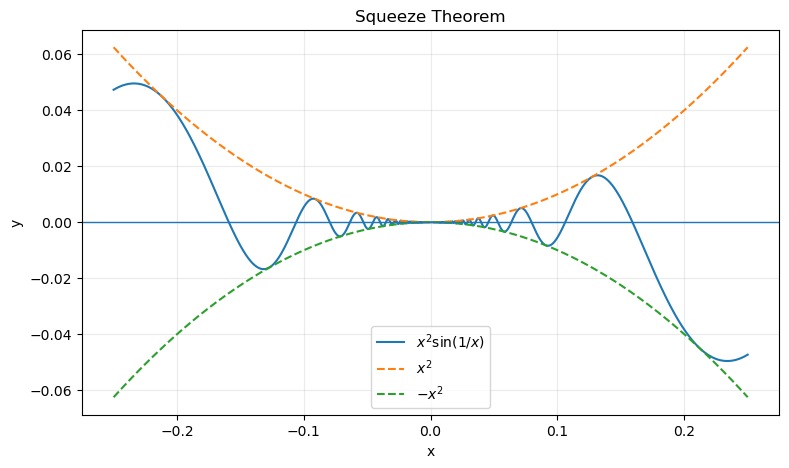

In [16]:
x_left = np.linspace(-0.25, -0.002, 1800)
x_right = np.linspace(0.002, 0.25, 1800)
xs = np.concatenate([x_left, x_right])

middle = xs**2 * np.sin(1/xs)
upper = xs**2
lower = -xs**2

plt.figure(figsize=(9, 5))
plt.plot(xs, middle, label=r"$x^2\sin(1/x)$")
plt.plot(xs, upper, linestyle="--", label=r"$x^2$")
plt.plot(xs, lower, linestyle="--", label=r"$-x^2$")
plt.axhline(0, linewidth=1)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Squeeze Theorem")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [17]:
squeeze_expr = x**2 * sp.sin(1/x)
print("Exact symbolic limit:", sp.limit(squeeze_expr, x, 0))

Exact symbolic limit: 0


## 10. L'Hopital's Rule

If a quotient has the indeterminate form $0/0$ and the hypotheses of L'Hopital's Rule are satisfied, then


$\lim_{x\to a}\frac{f(x)}{g(x)}
= \lim_{x\to a}\frac{f'(x)}{g'(x)},$


provided the limit on the right exists.

Lecture example:


$\lim_{x\to0}\frac{e^x-1}{x}.$

In [18]:
numerator = sp.exp(x) - 1
denominator = x

print("Numerator at 0 :", numerator.subs(x, 0))
print("Denominator at 0:", denominator.subs(x, 0))

num_prime = sp.diff(numerator, x)
den_prime = sp.diff(denominator, x)

print("Derivative of numerator  :", num_prime)
print("Derivative of denominator:", den_prime)

lhopital_limit = sp.limit(num_prime / den_prime, x, 0)
direct_symbolic_limit = sp.limit(numerator / denominator, x, 0)

print("L'Hopital result:", lhopital_limit)
print("SymPy limit     :", direct_symbolic_limit)

Numerator at 0 : 0
Denominator at 0: 0
Derivative of numerator  : exp(x)
Derivative of denominator: 1
L'Hopital result: 1
SymPy limit     : 1


### L'Hopital rule: example 2

Evaluate

$\lim_{x\to1}\frac{\ln x}{x-1}.$

Direct substitution gives $0/0$, so L'Hopital's Rule is applicable.

In [19]:
revision_lhopital = sp.log(x) / (x - 1)

print("Original limit:", sp.limit(revision_lhopital, x, 1))

derivative_ratio = sp.diff(sp.log(x), x) / sp.diff(x - 1, x)
print("Derivative ratio:", derivative_ratio)
print("Limit after differentiation:", sp.limit(derivative_ratio, x, 1))

Original limit: 1
Derivative ratio: 1/x
Limit after differentiation: 1


## 11. Limits at infinity and horizontal asymptotes

For rational functions, compare the highest powers.

Lecture example:

$\lim_{x\to\infty}
\frac{3x^2+2x-1}{x^2-5}=3.$


This also tells us that $y=3$ is a horizontal asymptote.

In [20]:
infinity_expr = (3*x**2 + 2*x - 1) / (x**2 - 5)

print("Exact limit at infinity:", sp.limit(infinity_expr, x, sp.oo))

Exact limit at infinity: 3


In [21]:
large_x = np.array([10, 100, 1_000, 10_000, 1_000_000], dtype=float)

def infinity_numeric(z):
    return (3*z**2 + 2*z - 1) / (z**2 - 5)

display(pd.DataFrame({
    "x": large_x,
    "f(x)": infinity_numeric(large_x),
    "distance from 3": np.abs(infinity_numeric(large_x) - 3)
}))

,x,f(x),distance from 3
0,10.0,3.357895,0.357895
1,100.0,3.021411,0.021411
2,1000.0,3.002014,0.002014
3,10000.0,3.000200,0.000200
4,1000000.0,3.000002,0.000002


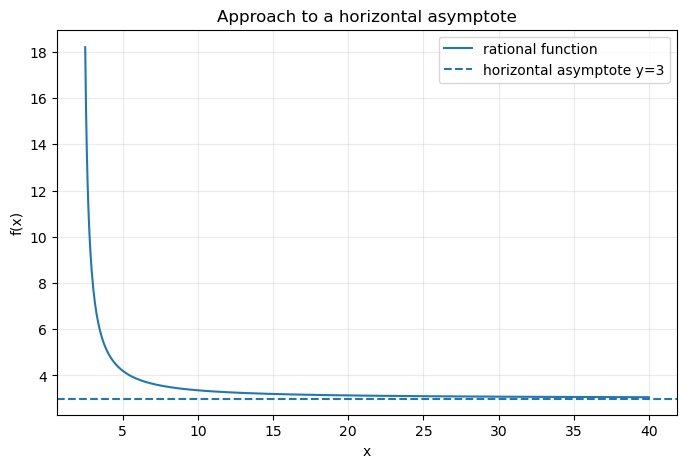

In [22]:
x_inf = np.linspace(2.5, 40, 700)
y_inf = infinity_numeric(x_inf)

plt.figure(figsize=(8, 5))
plt.plot(x_inf, y_inf, label="rational function")
plt.axhline(3, linestyle="--", label="horizontal asymptote y=3")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Approach to a horizontal asymptote")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 12. Exponential and logarithmic limits

Two examples from the lecture are

$\lim_{x\to\infty}e^{-x}=0,
\qquad
\lim_{x\to\infty}\frac{\ln x}{x}=0.$

These illustrate different growth rates.

In [23]:
print("lim exp(-x) as x -> infinity:",
      sp.limit(sp.exp(-x), x, sp.oo))

print("lim log(x)/x as x -> infinity:",
      sp.limit(sp.log(x)/x, x, sp.oo))

lim exp(-x) as x -> infinity: 0
lim log(x)/x as x -> infinity: 0


In [24]:
growth_x = np.array([2, 5, 10, 50, 100, 1000], dtype=float)

display(pd.DataFrame({
    "x": growth_x,
    "exp(-x)": np.exp(-growth_x),
    "ln(x)/x": np.log(growth_x) / growth_x
}))

,x,exp(-x),ln(x)/x
0,2.0,1.353353e-01,0.346574
1,5.0,6.737947e-03,0.321888
2,10.0,4.539993e-05,0.230259
3,50.0,1.928750e-22,0.078240
4,100.0,3.720076e-44,0.046052
5,1000.0,0.000000e+00,0.006908


## 13. Continuity at a point

A function is continuous at $x=a$ if all three conditions hold:

1. $f(a)$ is defined.
2. $\lim_{x\to a}f(x)$ exists.
3. $\lim_{x\to a}f(x)=f(a)$.

A practical test is


$\lim_{x\to a^-}f(x) =\lim_{x\to a^+}f(x)=f(a).$

In [25]:
def symbolic_continuity_report(expr, variable, point):
    """Print a simple symbolic continuity report at one point."""
    left = sp.limit(expr, variable, point, dir="-")
    right = sp.limit(expr, variable, point, dir="+")
    value = expr.subs(variable, point)

    print("Left-hand limit :", left)
    print("Right-hand limit:", right)
    print("Function value  :", value)

    is_continuous = (
        left == right and
        value is not sp.nan and
        left == value
    )

    print("Continuous?     :", is_continuous)

# Example from the lecture.
continuous_piece = sp.Piecewise(
    (x + 2, x < 1),
    (3, sp.Eq(x, 1)),
    (2*x + 1, True)
)

symbolic_continuity_report(continuous_piece, x, 1)

Left-hand limit : 3
Right-hand limit: 3
Function value  : 3
Continuous?     : True


## 14. Choosing a parameter to make a function continuous

Lecture example:

$f(x)=
\begin{cases}
x^2+1,&x<2,\\
kx,&x\ge2.
\end{cases}$

Find $k$ so that $f$ is continuous at $x=2$.

Continuity requires the left-hand limit to equal $f(2)$.

In [26]:
k = sp.symbols("k", real=True)

left_expression = x**2 + 1
right_expression = k*x

left_at_2 = sp.limit(left_expression, x, 2, dir="-")
right_value_at_2 = right_expression.subs(x, 2)

solution_k = sp.solve(sp.Eq(left_at_2, right_value_at_2), k)

print("Left-hand limit at x=2:", left_at_2)
print("Function value from right branch:", right_value_at_2)
print("Required k:", solution_k)

Left-hand limit at x=2: 5
Function value from right branch: 2*k
Required k: [5/2]


## 15. Types of discontinuity

The lecture identifies three important types:

- **Removable:** a hole exists, but the limit exists.
- **Jump:** left and right limits are finite but unequal.
- **Infinite:** the function grows without bound near the point.

We visualize each separately.

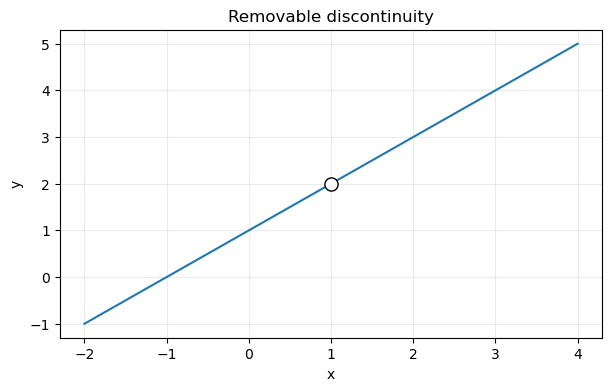

In [27]:
# Removable discontinuity
xr = np.linspace(-2, 4, 600)
yr = xr + 1

plt.figure(figsize=(7, 4))
plt.plot(xr, yr)
plt.scatter([1], [2], facecolors="white", edgecolors="black", s=90, zorder=5)
plt.title("Removable discontinuity")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.25)
plt.show()

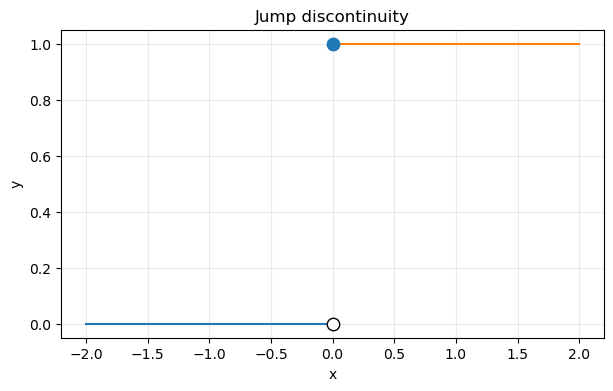

In [28]:
# Jump discontinuity
xj_left = np.linspace(-2, 0, 300, endpoint=False)
xj_right = np.linspace(0, 2, 300)

plt.figure(figsize=(7, 4))
plt.plot(xj_left, np.zeros_like(xj_left))
plt.plot(xj_right, np.ones_like(xj_right))

plt.scatter([0], [0], facecolors="white", edgecolors="black", s=80, zorder=5)
plt.scatter([0], [1], s=80, zorder=6)

plt.title("Jump discontinuity")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.25)
plt.show()

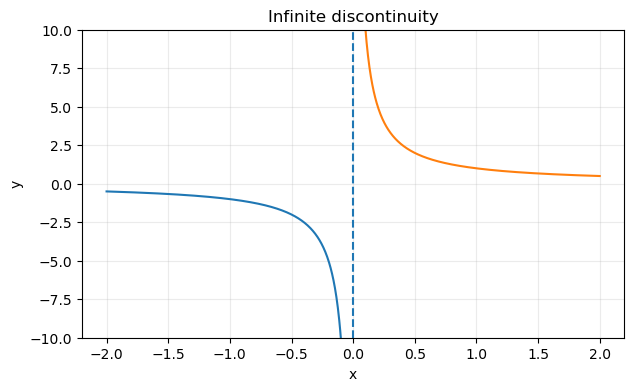

In [29]:
# Infinite discontinuity
xi_left = np.linspace(-2, -0.05, 500)
xi_right = np.linspace(0.05, 2, 500)

plt.figure(figsize=(7, 4))
plt.plot(xi_left, 1/xi_left)
plt.plot(xi_right, 1/xi_right)
plt.axvline(0, linestyle="--")

plt.ylim(-10, 10)
plt.title("Infinite discontinuity")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.25)
plt.show()

## 16. Intermediate Value Theorem (IVT)

If $f$ is continuous on $[a,b]$, and $N$ lies between $f(a)$ and $f(b)$, then there is at least one $c\in(a,b)$ such that

$f(c)=N.$

For finding a root, take $N=0$.

Lecture example:

$f(x)=x^3+x-1.$

Since

$f(0)=-1,\qquad f(1)=1,$

and the function is a polynomial, IVT guarantees at least one root in $(0,1)$.

SciPy can then **numerically locate** the root.

In [30]:
def ivt_function(z):
    return z**3 + z - 1

a, b = 0.0, 1.0

print("f(a) =", ivt_function(a))
print("f(b) =", ivt_function(b))
print("Sign change?", ivt_function(a) * ivt_function(b) < 0)

# Brent's method is a robust bracketed root-finding algorithm.
root_result = optimize.root_scalar(
    ivt_function,
    bracket=[a, b],
    method="brentq"
)

print("Converged:", root_result.converged)
print("Approximate root:", root_result.root)
print("Residual f(root):", ivt_function(root_result.root))

f(a) = -1.0
f(b) = 1.0
Sign change? True
Converged: True
Approximate root: 0.682327803828082
Residual f(root): 1.5010215292932116e-13


### A second IVT example

The lecture also considers


$f(x)=x^3-4x+1$

on $[0,1]$. Verify the sign change and locate a root with SciPy.

In [31]:
def ivt_function_2(z):
    return z**3 - 4*z + 1

print("f(0) =", ivt_function_2(0))
print("f(1) =", ivt_function_2(1))

root_result_2 = optimize.root_scalar(
    ivt_function_2,
    bracket=[0, 1],
    method="brentq"
)

print("Approximate root:", root_result_2.root)
print("Residual:", ivt_function_2(root_result_2.root))

f(0) = 1
f(1) = -2
Approximate root: 0.25410168836509694
Residual: -1.694200335577989e-13


## 17. Continuity versus differentiability

The lecture emphasizes:

> If $f$ is differentiable at $x=a$, then it is continuous at $x=a$.

The converse is false.

The standard example is

$f(x)=|x|.$

It is continuous at $0$, but it has a sharp corner there.

In [32]:
abs_expr = sp.Abs(x)

print("Left limit :", sp.limit(abs_expr, x, 0, dir="-"))
print("Right limit:", sp.limit(abs_expr, x, 0, dir="+"))
print("f(0)       :", abs_expr.subs(x, 0))

Left limit : 0
Right limit: 0
f(0)       : 0


The derivative is defined by the limit

$f'(x)=
\lim_{h\to0}
\frac{f(x+h)-f(x)}{h}.$


At $x=0$ for $f(x)=|x|$:

$\frac{|h|-0}{h}
=\frac{|h|}{h}.$

From the left the quotient approaches $-1$; from the right it approaches $1$.

In [33]:
h = sp.symbols("h", real=True)
difference_quotient_abs = sp.Abs(h) / h

left_derivative = sp.limit(difference_quotient_abs, h, 0, dir="-")
right_derivative = sp.limit(difference_quotient_abs, h, 0, dir="+")

print("Left derivative :", left_derivative)
print("Right derivative:", right_derivative)
print("Derivative exists at 0?", left_derivative == right_derivative)

Left derivative : -1
Right derivative: 1
Derivative exists at 0? False


## 18. Derivative from first principles

For


$f(x)=x^2,$

the derivative is obtained from

$f'(x)=
\lim_{h\to0}
\frac{(x+h)^2-x^2}{h}.$

In [34]:
h = sp.symbols("h", real=True)

f = x**2
difference_quotient = ((x + h)**2 - x**2) / h

print("Difference quotient:", sp.expand(difference_quotient))
print("Simplified quotient:", sp.simplify(difference_quotient))
print("Derivative from limit:", sp.limit(difference_quotient, h, 0))
print("SymPy derivative     :", sp.diff(f, x))

Difference quotient: h + 2*x
Simplified quotient: h + 2*x
Derivative from limit: 2*x
SymPy derivative     : 2*x


## 19. The Chain Rule

Lecture example:


$y=(3x^2+1)^5.$

By the chain rule,

$y'=30x(3x^2+1)^4.$

We can use SymPy to verify the result.

In [35]:
chain_expr = (3*x**2 + 1)**5
chain_derivative = sp.diff(chain_expr, x)

print("Derivative:\n")
sp.pprint(sp.factor(chain_derivative))

Derivative:

               4
     ⎛   2    ⎞ 
30⋅x⋅⎝3⋅x  + 1⎠ 


## 20. Rates of change

If position is

$s(t)=t^2+3t,$

then velocity is

$v(t)=s'(t)=2t+3.$

At $t=4$, $v(4)=11$.

In [36]:
t = sp.symbols("t", real=True)

s = t**2 + 3*t
v = sp.diff(s, t)

print("Position s(t):", s)
print("Velocity v(t):", v)
print("Velocity at t=4:", v.subs(t, 4))

Position s(t): t**2 + 3*t
Velocity v(t): 2*t + 3
Velocity at t=4: 11


## 21. Optimization with derivatives and SciPy

Lecture cost model:


$C(x)=x^2-10x+40.$

Calculus gives

$C'(x)=2x-10=0
\quad\Rightarrow\quad
x=5.$

Since $C''(x)=2>0$, this is a minimum.

SciPy can find the same minimum numerically.

In [37]:
cost_expr = x**2 - 10*x + 40

first_derivative = sp.diff(cost_expr, x)
second_derivative = sp.diff(cost_expr, x, 2)
critical_points = sp.solve(sp.Eq(first_derivative, 0), x)

print("C'(x) =", first_derivative)
print("C''(x) =", second_derivative)
print("Critical point(s):", critical_points)

C'(x) = 2*x - 10
C''(x) = 2
Critical point(s): [5]


In [38]:
def cost_numeric(z):
    return z**2 - 10*z + 40

minimum = optimize.minimize_scalar(cost_numeric)

print("Optimization successful:", minimum.success)
print("x minimizing cost:", minimum.x)
print("Minimum cost:", minimum.fun)

Optimization successful: True
x minimizing cost: 5.0
Minimum cost: 15.0


## 22. Long-run algorithm growth

Limits help compare growth rates.

For example, compare

$n\log n
\quad\text{and}\quad
n^2.$

Consider


$\lim_{n\to\infty}\frac{n\log n}{n^2}
=\lim_{n\to\infty}\frac{\log n}{n}
=0.$


This means $n\log n$ grows asymptotically more slowly than $n^2$.

In [39]:
n = sp.symbols("n", positive=True)

growth_ratio = (n * sp.log(n)) / n**2
print("Symbolic limit:", sp.limit(growth_ratio, n, sp.oo))

Symbolic limit: 0


In [40]:
n_values = np.array([10, 100, 1_000, 10_000, 1_000_000], dtype=float)

display(pd.DataFrame({
    "n": n_values,
    "n log(n)": n_values * np.log(n_values),
    "n^2": n_values**2,
    "(n log n)/(n^2)": np.log(n_values) / n_values
}))

,n,n log(n),n^2,(n log n)/(n^2)
0,10.0,2.302585e+01,1.000000e+02,0.230259
1,100.0,4.605170e+02,1.000000e+04,0.046052
2,1000.0,6.907755e+03,1.000000e+06,0.006908
3,10000.0,9.210340e+04,1.000000e+08,0.000921
4,1000000.0,1.381551e+07,1.000000e+12,0.000014


## 23. A reusable numerical limit estimator

The following function is **not a proof** that a limit exists. It is an experimental tool that compares values from the left and right.

It is useful for developing intuition and checking symbolic work.

In [41]:
def estimate_limit(func, a, h_values=None):
    """Numerically sample a function from the left and right of a.

    This is an exploratory numerical tool, not a rigorous proof.
    """
    if h_values is None:
        h_values = 10.0 ** (-np.arange(1, 9, dtype=float))

    records = []

    for h_val in h_values:
        left_x = a - h_val
        right_x = a + h_val

        records.append({
            "h": h_val,
            "left_x": left_x,
            "f(left_x)": func(left_x),
            "right_x": right_x,
            "f(right_x)": func(right_x),
            "left-right gap": abs(func(left_x) - func(right_x))
        })

    return pd.DataFrame(records)

display(estimate_limit(lambda z: (z**2 - 1)/(z - 1), 1))

,h,left_x,f(left_x),right_x,f(right_x),left-right gap
0,1.000000e-01,0.900000,1.900000,1.100000,2.100000,2.000000e-01
1,1.000000e-02,0.990000,1.990000,1.010000,2.010000,2.000000e-02
2,1.000000e-03,0.999000,1.999000,1.001000,2.001000,2.000000e-03
3,1.000000e-04,0.999900,1.999900,1.000100,2.000100,2.000000e-04
4,1.000000e-05,0.999990,1.999990,1.000010,2.000010,2.000000e-05
5,1.000000e-06,0.999999,1.999999,1.000001,2.000001,2.000067e-06
6,1.000000e-07,1.000000,2.000000,1.000000,2.000000,1.998401e-07
7,1.000000e-08,1.000000,2.000000,1.000000,2.000000,1.110223e-08


### Warning about numerical evidence

A table can strongly suggest a limit, but numerical sampling alone can be misleading.

For example:

- the function may oscillate rapidly between sampled points;
- floating-point arithmetic may introduce round-off error;
- a very large finite value is not the same thing as $+\infty$;
- matching a few left/right values does not constitute a formal proof.

Use numerical evidence together with algebraic or theoretical reasoning.